# End-to-End Machine Learning Project: Forex Currency Prediction

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as mso
import pmdarima as pm
from sklearn.metrics import mean_absolute_error, mean_squared_error
from prophet import Prophet

from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam 

import os
import joblib

In [10]:
#loading data
data = pd.read_csv("Foreign_Exchange_Rates.xls")
data.head()

,Unnamed: 0,Time Serie,AUSTRALIA - AUSTRALIAN DOLLAR/US$,EURO AREA - EURO/US$,NEW ZEALAND - NEW ZELAND DOLLAR/US$,UNITED KINGDOM - UNITED KINGDOM POUND/US$,BRAZIL - REAL/US$,CANADA - CANADIAN DOLLAR/US$,CHINA - YUAN/US$,HONG KONG - HONG KONG DOLLAR/US$,...,DENMARK - DANISH KRONE/US$,JAPAN - YEN/US$,MALAYSIA - RINGGIT/US$,NORWAY - NORWEGIAN KRONE/US$,SWEDEN - KRONA/US$,SRI LANKA - SRI LANKAN RUPEE/US$,SWITZERLAND - FRANC/US$,TAIWAN - NEW TAIWAN DOLLAR/US$,THAILAND - BAHT/US$,Unnamed: 24
0,0,03-01-2000,1.5172,0.9847,1.9033,0.6146,1.805,1.4465,8.2798,7.7765,...,7.329,101.7,3.8,7.964,8.443,72.3,1.5808,31.38,36.97,NaN
1,1,04-01-2000,1.5239,0.97,1.9238,0.6109,1.8405,1.4518,8.2799,7.7775,...,7.218,103.09,3.8,7.934,8.36,72.65,1.5565,30.6,37.13,NaN
2,2,05-01-2000,1.5267,0.9676,1.9339,0.6092,1.856,1.4518,8.2798,7.778,...,7.208,103.77,3.8,7.935,8.353,72.95,1.5526,30.8,37.1,NaN
3,3,06-01-2000,1.5291,0.9686,1.9436,0.607,1.84,1.4571,8.2797,7.7785,...,7.2125,105.19,3.8,7.94,8.3675,72.95,1.554,31.75,37.62,NaN
4,4,07-01-2000,1.5272,0.9714,1.938,0.6104,1.831,1.4505,8.2794,7.7783,...,7.2285,105.17,3.8,7.966,8.415,73.15,1.5623,30.85,37.3,NaN


In [11]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5217 entries, 0 to 5216
Data columns (total 25 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Unnamed: 0                                 5217 non-null   int64  
 1   Time Serie                                 5217 non-null   str    
 2   AUSTRALIA - AUSTRALIAN DOLLAR/US$          5217 non-null   str    
 3   EURO AREA - EURO/US$                       5217 non-null   str    
 4   NEW ZEALAND - NEW ZELAND DOLLAR/US$        5217 non-null   str    
 5   UNITED KINGDOM - UNITED KINGDOM POUND/US$  5217 non-null   str    
 6   BRAZIL - REAL/US$                          5217 non-null   str    
 7   CANADA - CANADIAN DOLLAR/US$               5217 non-null   str    
 8   CHINA - YUAN/US$                           5217 non-null   str    
 9   HONG KONG - HONG KONG DOLLAR/US$           5217 non-null   str    
 10  INDIA - INDIAN RUPEE/US$           

In [12]:
#dropping null values and converting timeseries to datetime 
data.dropna()
data['Time Serie'] = pd.to_datetime(data['Time Serie'], format='%d-%m-%Y')

### Pre-processing code

In [4]:
# Drop column filled with missingness
data = data.drop(columns="Unnamed: 24")

In [7]:
# Check for unique values

data['AUSTRALIA - AUSTRALIAN DOLLAR/US$'].value_counts()

AUSTRALIA - AUSTRALIAN DOLLAR/US$
ND        198
1.3943      8
1.3263      8
1.3033      8
1.2958      7
         ... 
1.4596      1
1.4628      1
1.4489      1
1.4445      1
1.4411      1
Name: count, Length: 2959, dtype: int64

In [5]:
# Replace ND with missing values

data = data.replace("ND", pd.NA)

In [7]:
data.isna().sum()

Unnamed: 0                                     0
Time Serie                                     0
AUSTRALIA - AUSTRALIAN DOLLAR/US$            198
EURO AREA - EURO/US$                         198
NEW ZEALAND - NEW ZELAND DOLLAR/US$          198
UNITED KINGDOM - UNITED KINGDOM POUND/US$    198
BRAZIL - REAL/US$                            198
CANADA - CANADIAN DOLLAR/US$                 198
CHINA - YUAN/US$                             197
HONG KONG - HONG KONG DOLLAR/US$             198
INDIA - INDIAN RUPEE/US$                     199
KOREA - WON/US$                              198
MEXICO - MEXICAN PESO/US$                    198
SOUTH AFRICA - RAND/US$                      198
SINGAPORE - SINGAPORE DOLLAR/US$             198
DENMARK - DANISH KRONE/US$                   198
JAPAN - YEN/US$                              198
MALAYSIA - RINGGIT/US$                       198
NORWAY - NORWEGIAN KRONE/US$                 198
SWEDEN - KRONA/US$                           198
SRI LANKA - SRI LANK

<Axes: >

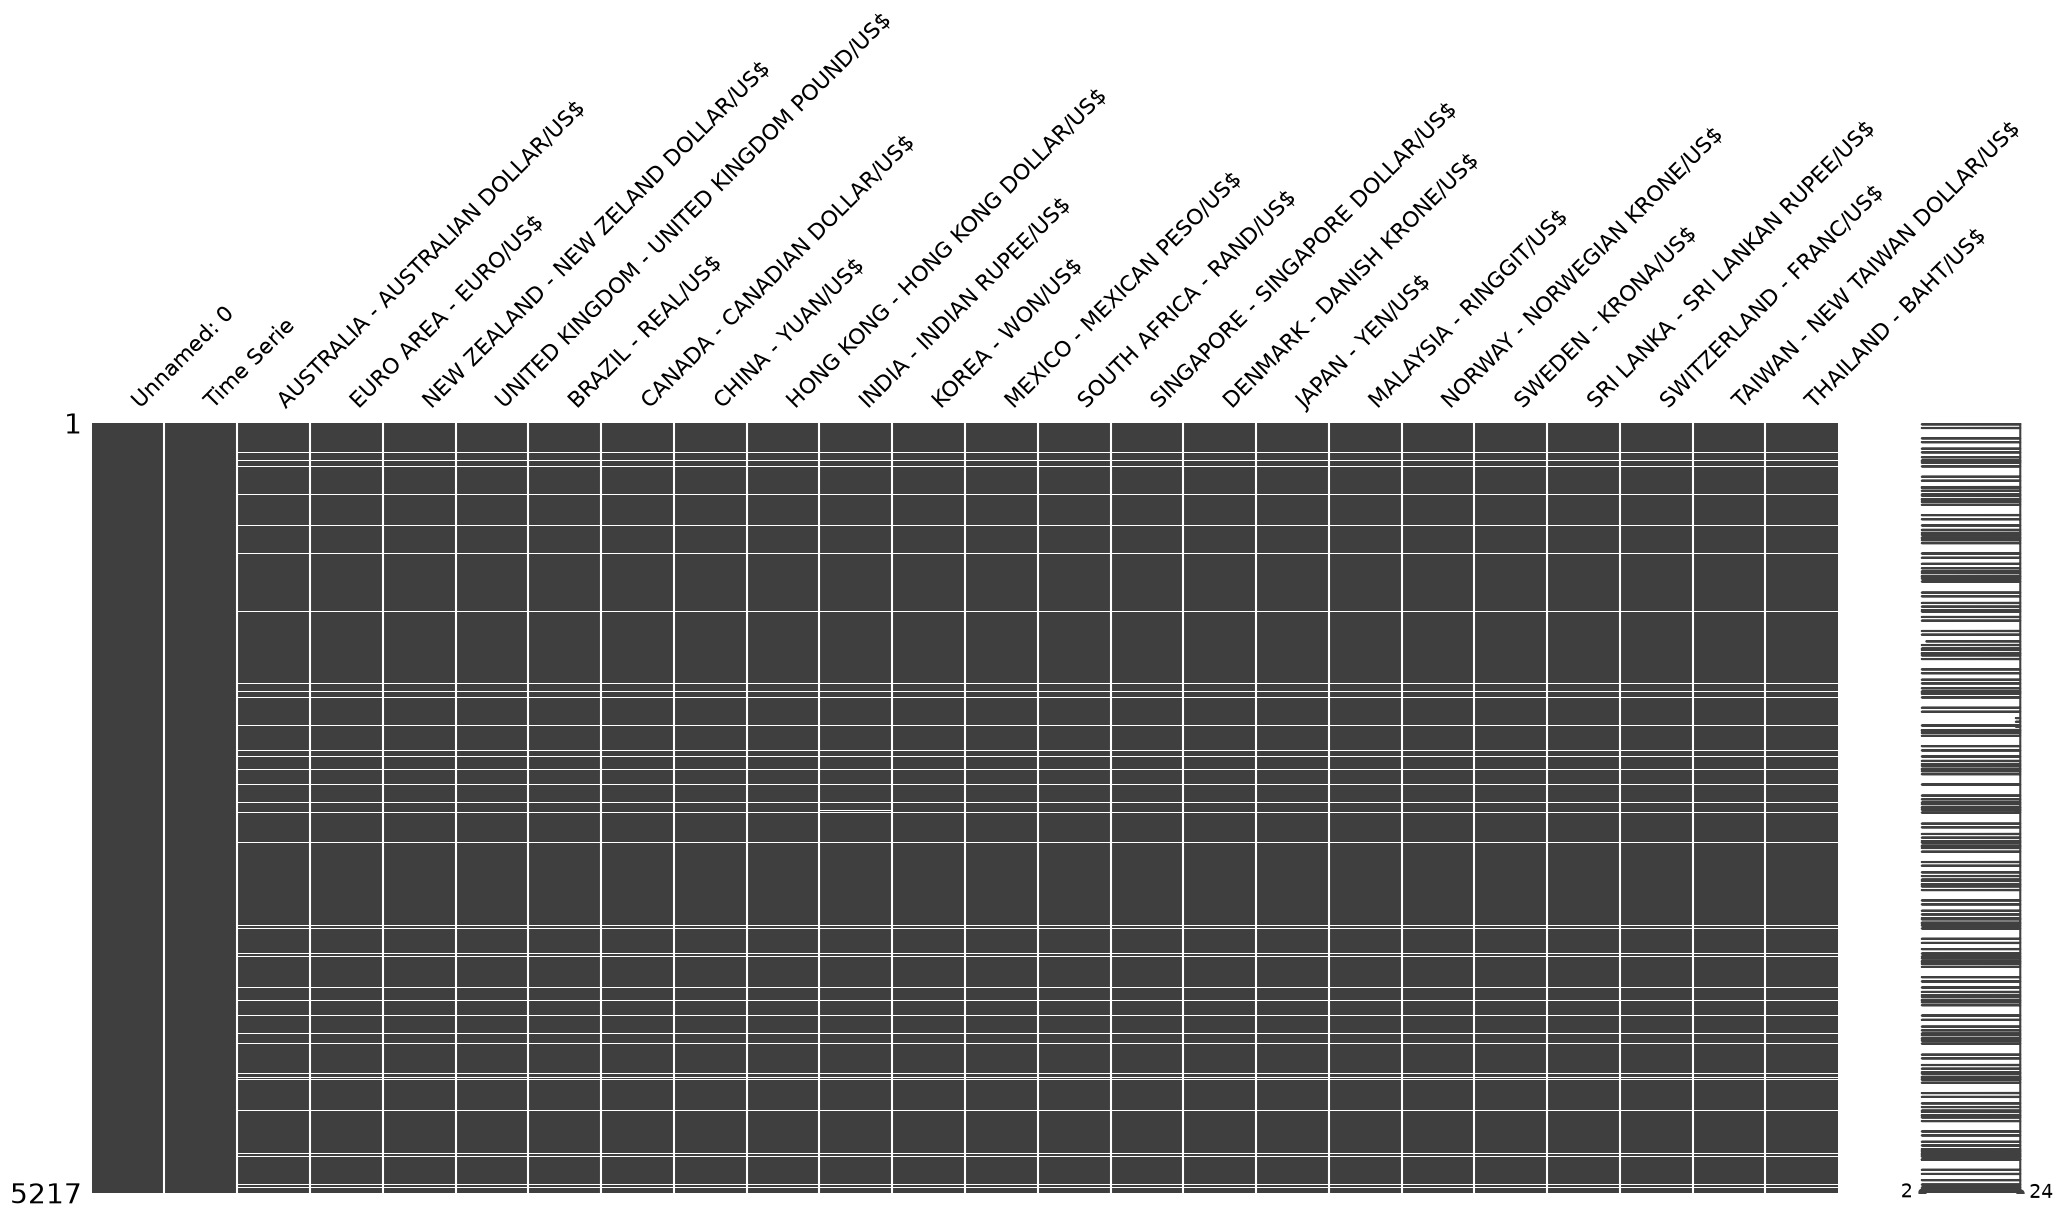

In [8]:
# Visualise missingness to identify pattern
mso.matrix(data)

In [6]:
# Convert currencies to string
col = ['AUSTRALIA - AUSTRALIAN DOLLAR/US$',
       'EURO AREA - EURO/US$', 'NEW ZEALAND - NEW ZELAND DOLLAR/US$',
       'UNITED KINGDOM - UNITED KINGDOM POUND/US$', 'BRAZIL - REAL/US$',
       'CANADA - CANADIAN DOLLAR/US$', 'CHINA - YUAN/US$',
       'HONG KONG - HONG KONG DOLLAR/US$', 'INDIA - INDIAN RUPEE/US$',
       'KOREA - WON/US$', 'MEXICO - MEXICAN PESO/US$',
       'SOUTH AFRICA - RAND/US$', 'SINGAPORE - SINGAPORE DOLLAR/US$',
       'DENMARK - DANISH KRONE/US$', 'JAPAN - YEN/US$',
       'MALAYSIA - RINGGIT/US$', 'NORWAY - NORWEGIAN KRONE/US$',
       'SWEDEN - KRONA/US$', 'SRI LANKA - SRI LANKAN RUPEE/US$',
       'SWITZERLAND - FRANC/US$', 'TAIWAN - NEW TAIWAN DOLLAR/US$',
       'THAILAND - BAHT/US$']

data[col] = data[col].astype(float)


In [7]:
# Fill in missing values with linear interpolation
data = data.interpolate(method='linear')

In [11]:
print(data.shape)
data.isna().sum()

(5217, 24)


Unnamed: 0                                   0
Time Serie                                   0
AUSTRALIA - AUSTRALIAN DOLLAR/US$            0
EURO AREA - EURO/US$                         0
NEW ZEALAND - NEW ZELAND DOLLAR/US$          0
UNITED KINGDOM - UNITED KINGDOM POUND/US$    0
BRAZIL - REAL/US$                            0
CANADA - CANADIAN DOLLAR/US$                 0
CHINA - YUAN/US$                             0
HONG KONG - HONG KONG DOLLAR/US$             0
INDIA - INDIAN RUPEE/US$                     0
KOREA - WON/US$                              0
MEXICO - MEXICAN PESO/US$                    0
SOUTH AFRICA - RAND/US$                      0
SINGAPORE - SINGAPORE DOLLAR/US$             0
DENMARK - DANISH KRONE/US$                   0
JAPAN - YEN/US$                              0
MALAYSIA - RINGGIT/US$                       0
NORWAY - NORWEGIAN KRONE/US$                 0
SWEDEN - KRONA/US$                           0
SRI LANKA - SRI LANKAN RUPEE/US$             0
SWITZERLAND -

In [8]:
data = data.rename(columns={'Unnamed: 0': 'Days'})

### EDA

In [13]:
data.head()

,Days,Time Serie,AUSTRALIA - AUSTRALIAN DOLLAR/US$,EURO AREA - EURO/US$,NEW ZEALAND - NEW ZELAND DOLLAR/US$,UNITED KINGDOM - UNITED KINGDOM POUND/US$,BRAZIL - REAL/US$,CANADA - CANADIAN DOLLAR/US$,CHINA - YUAN/US$,HONG KONG - HONG KONG DOLLAR/US$,...,SINGAPORE - SINGAPORE DOLLAR/US$,DENMARK - DANISH KRONE/US$,JAPAN - YEN/US$,MALAYSIA - RINGGIT/US$,NORWAY - NORWEGIAN KRONE/US$,SWEDEN - KRONA/US$,SRI LANKA - SRI LANKAN RUPEE/US$,SWITZERLAND - FRANC/US$,TAIWAN - NEW TAIWAN DOLLAR/US$,THAILAND - BAHT/US$
0,0,2000-01-03,1.5172,0.9847,1.9033,0.6146,1.8050,1.4465,8.2798,7.7765,...,1.6563,7.3290,101.70,3.8,7.964,8.4430,72.30,1.5808,31.38,36.97
1,1,2000-01-04,1.5239,0.9700,1.9238,0.6109,1.8405,1.4518,8.2799,7.7775,...,1.6535,7.2180,103.09,3.8,7.934,8.3600,72.65,1.5565,30.60,37.13
2,2,2000-01-05,1.5267,0.9676,1.9339,0.6092,1.8560,1.4518,8.2798,7.7780,...,1.6560,7.2080,103.77,3.8,7.935,8.3530,72.95,1.5526,30.80,37.10
3,3,2000-01-06,1.5291,0.9686,1.9436,0.6070,1.8400,1.4571,8.2797,7.7785,...,1.6655,7.2125,105.19,3.8,7.940,8.3675,72.95,1.5540,31.75,37.62
4,4,2000-01-07,1.5272,0.9714,1.9380,0.6104,1.8310,1.4505,8.2794,7.7783,...,1.6625,7.2285,105.17,3.8,7.966,8.4150,73.15,1.5623,30.85,37.30


In [14]:
data.describe()

,Days,Time Serie,AUSTRALIA - AUSTRALIAN DOLLAR/US$,EURO AREA - EURO/US$,NEW ZEALAND - NEW ZELAND DOLLAR/US$,UNITED KINGDOM - UNITED KINGDOM POUND/US$,BRAZIL - REAL/US$,CANADA - CANADIAN DOLLAR/US$,CHINA - YUAN/US$,HONG KONG - HONG KONG DOLLAR/US$,...,SINGAPORE - SINGAPORE DOLLAR/US$,DENMARK - DANISH KRONE/US$,JAPAN - YEN/US$,MALAYSIA - RINGGIT/US$,NORWAY - NORWEGIAN KRONE/US$,SWEDEN - KRONA/US$,SRI LANKA - SRI LANKAN RUPEE/US$,SWITZERLAND - FRANC/US$,TAIWAN - NEW TAIWAN DOLLAR/US$,THAILAND - BAHT/US$
count,5217.000000,5217,5217.000000,5217.000000,5217.000000,5217.000000,5217.000000,5217.000000,5217.000000,5217.000000,...,5217.000000,5217.000000,5217.000000,5217.000000,5217.000000,5217.000000,5217.000000,5217.000000,5217.000000,5217.000000
mean,2608.000000,2009-12-31 09:36:19.873490,1.332292,0.844075,1.543670,0.640740,2.550725,1.230582,7.199296,7.782607,...,1.480206,6.287267,106.593463,3.652043,7.078513,7.901951,119.202686,1.150110,31.766663,35.520137
min,0.000000,2000-01-03 00:00:00,0.906900,0.624600,1.134600,0.473800,1.537500,0.916800,6.040200,7.708500,...,1.200700,4.660500,75.720000,2.937000,4.946700,5.834600,72.300000,0.729600,28.500000,28.600000
25%,1304.000000,2004-12-31 00:00:00,1.115600,0.751200,1.323800,0.587900,1.946000,1.056000,6.475800,7.756350,...,1.342900,5.594800,100.100000,3.293000,5.998800,6.853900,100.400000,0.966800,30.350000,31.780000
50%,2608.000000,2009-12-31 00:00:00,1.311500,0.815800,1.442600,0.636600,2.331000,1.237100,6.859700,7.780500,...,1.408500,6.074000,109.040000,3.800000,6.787700,7.750900,112.350000,1.038600,31.730000,34.000000
75%,3912.000000,2014-12-31 00:00:00,1.430600,0.900300,1.590700,0.692500,3.132000,1.335700,8.276500,7.799800,...,1.678700,6.715300,116.830000,3.800000,8.281200,8.747700,132.800000,1.268700,32.980000,39.420000
max,5216.000000,2019-12-31 00:00:00,2.071300,1.209200,2.551000,0.828700,4.259400,1.612800,8.280000,7.849900,...,1.854000,9.005000,134.770000,4.496000,9.589000,11.027000,182.800000,1.825000,35.210000,45.820000
std,1506.162508,NaN,0.269807,0.126697,0.337136,0.082644,0.725450,0.182145,0.819867,0.027556,...,0.188839,0.942473,13.222447,0.379208,1.227141,1.201904,25.412040,0.248851,1.670901,4.562262


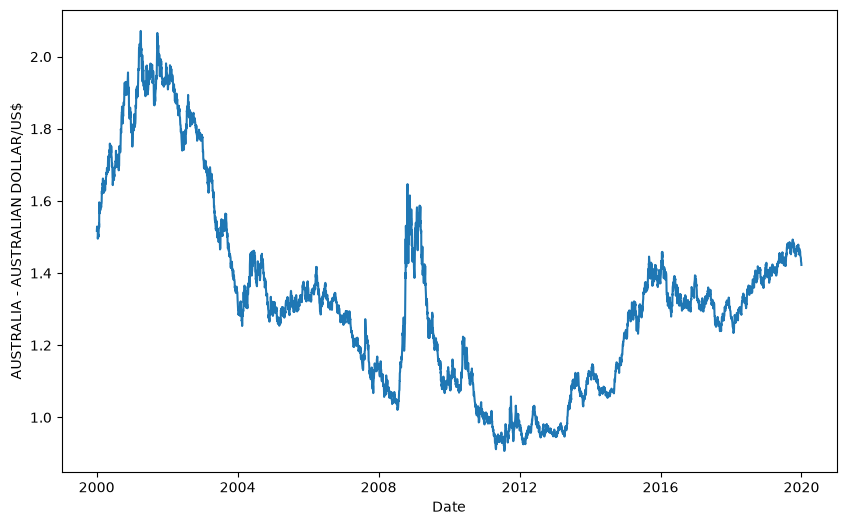

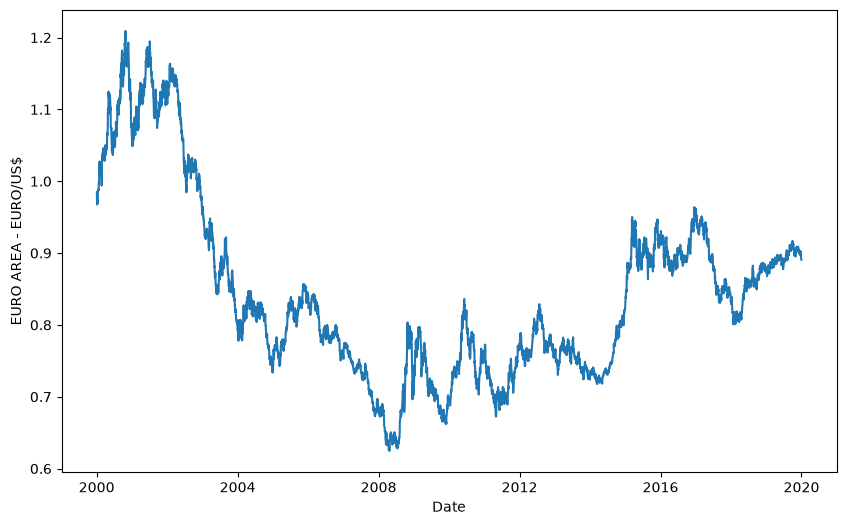

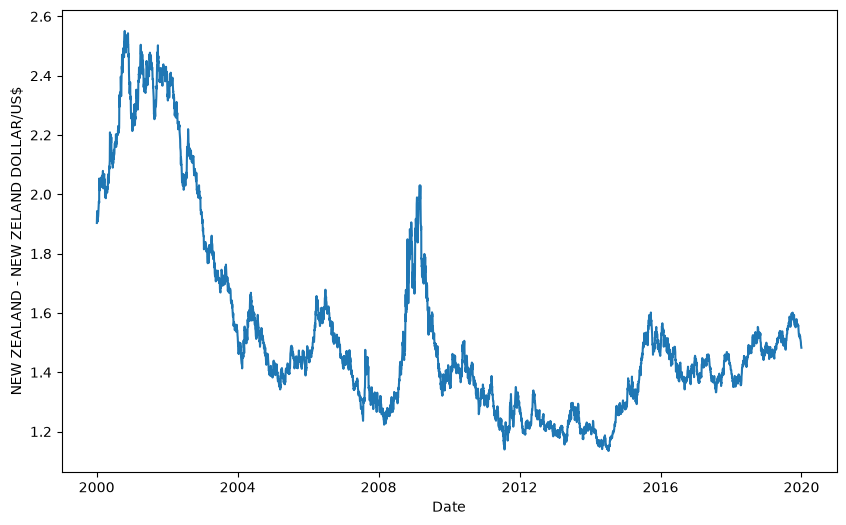

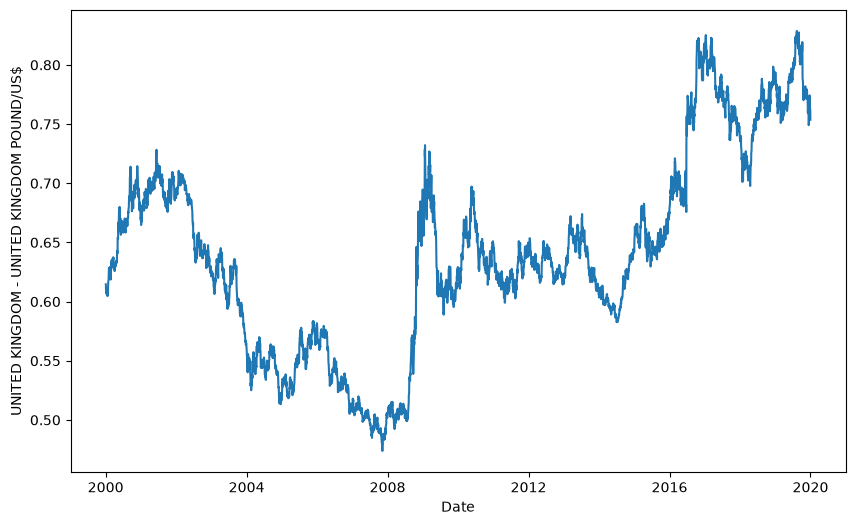

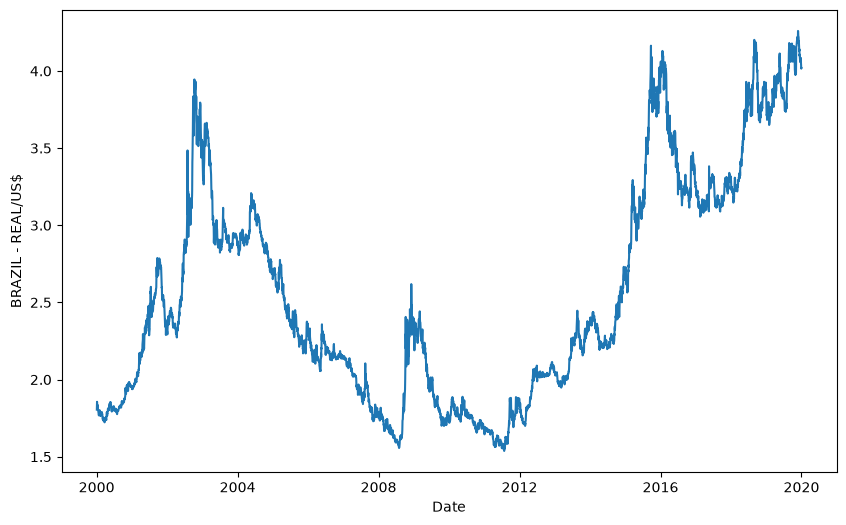

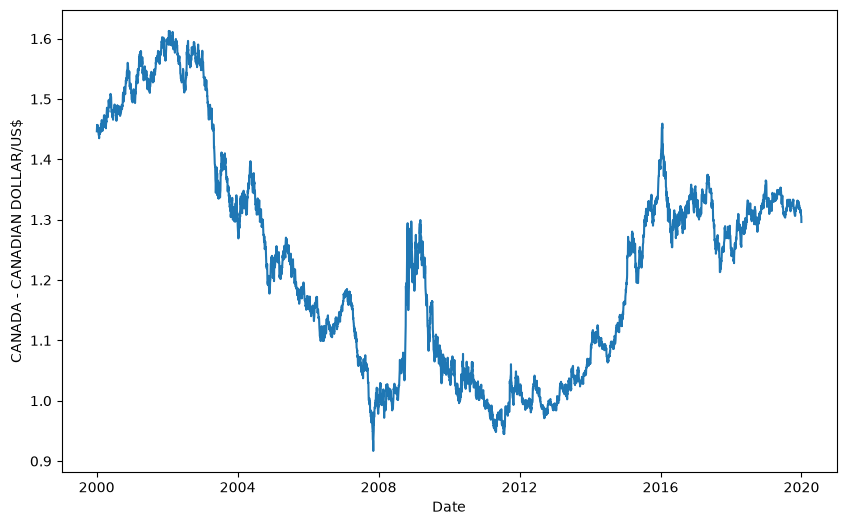

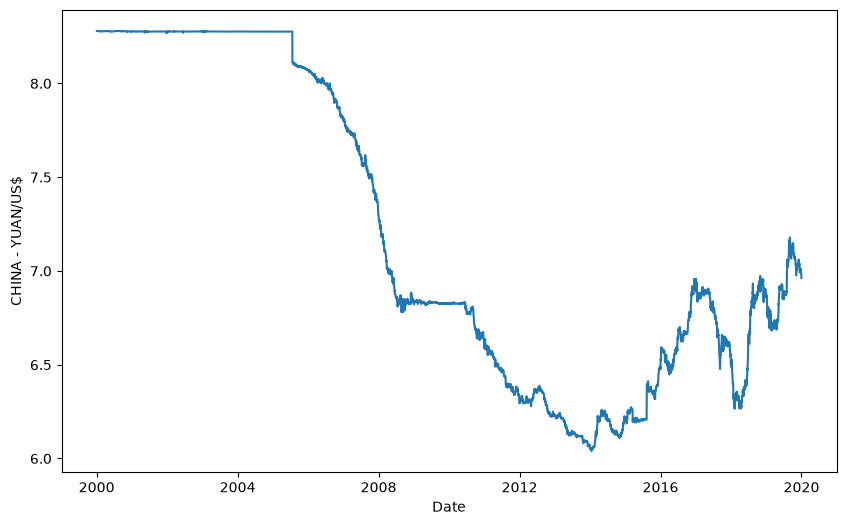

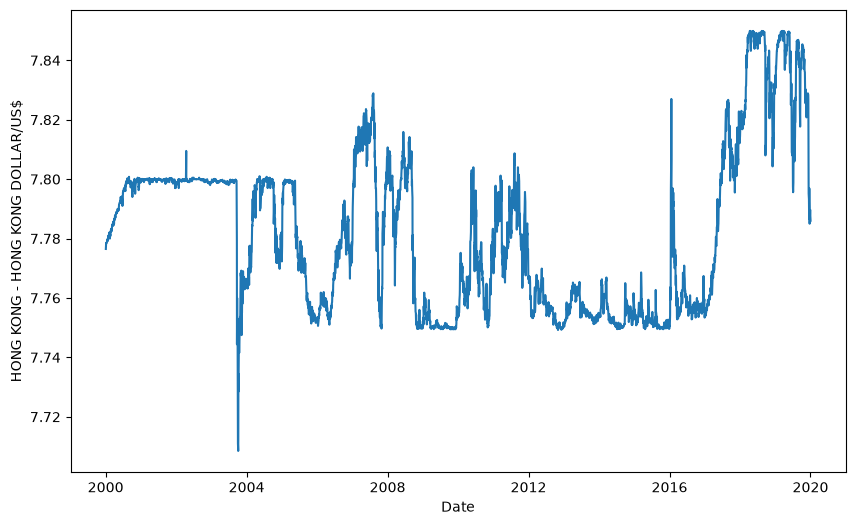

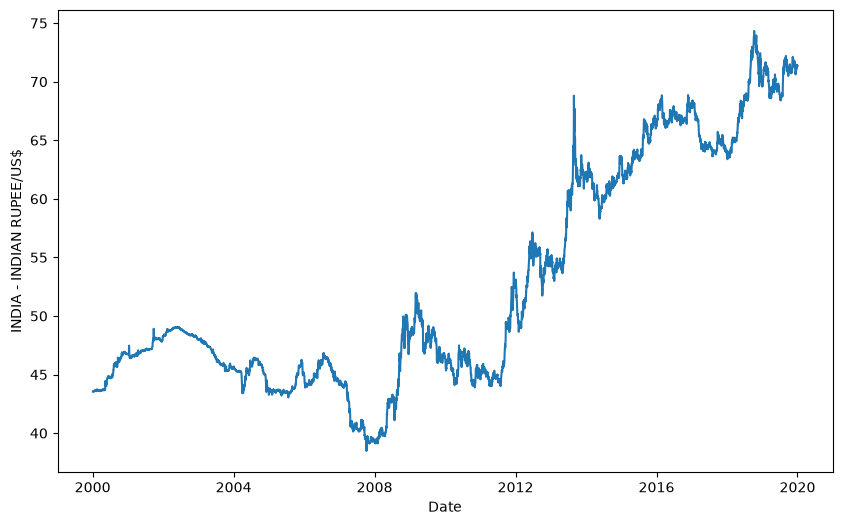

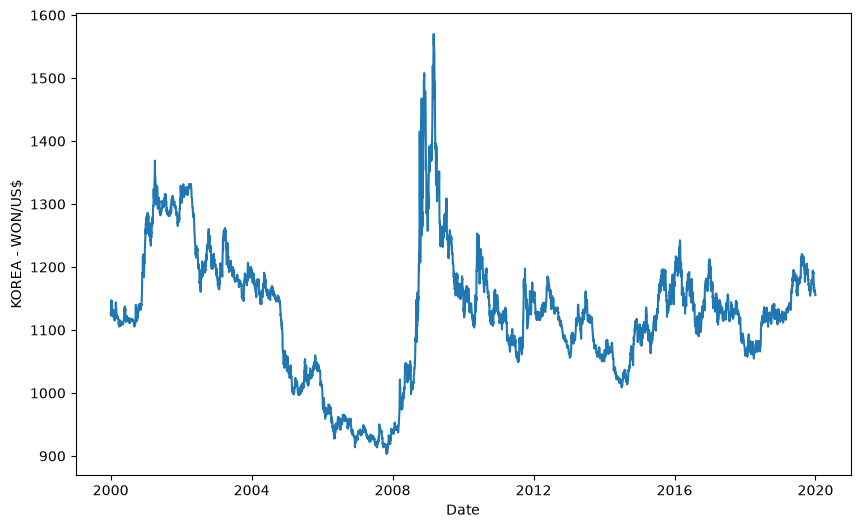

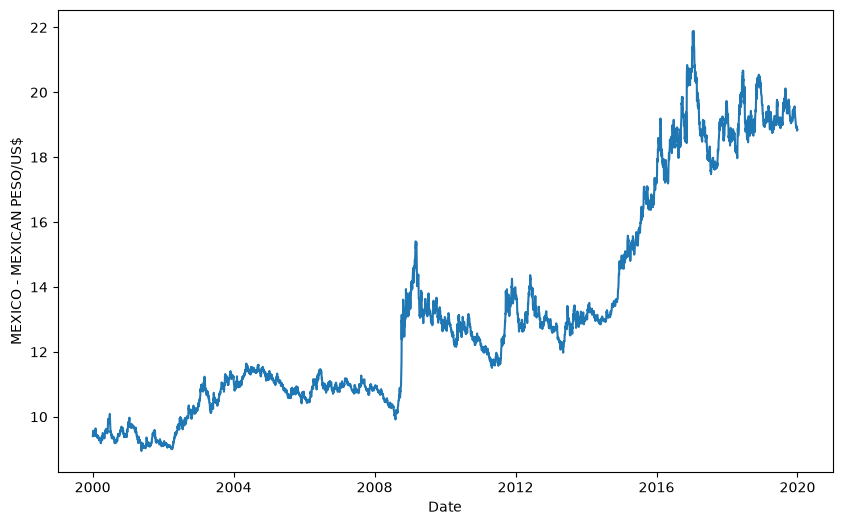

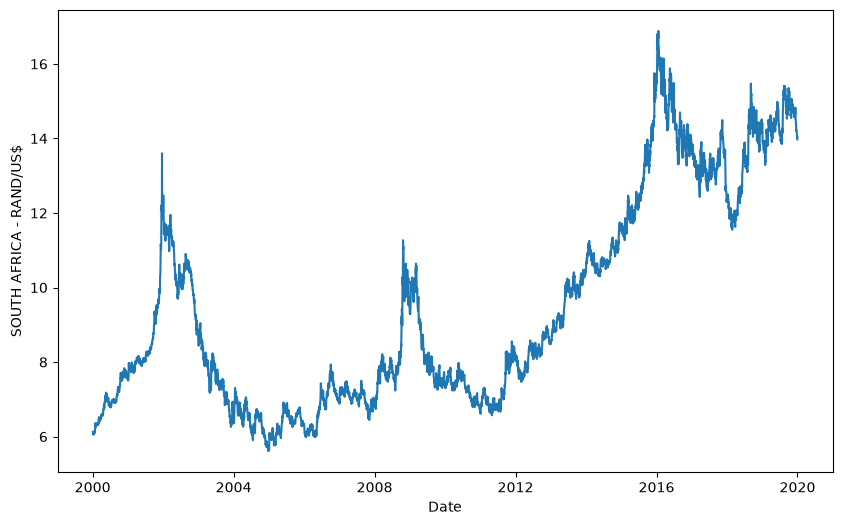

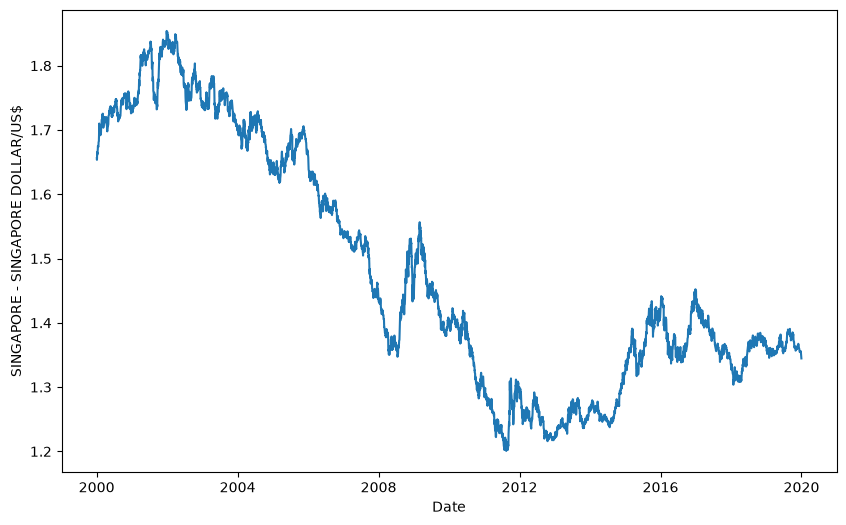

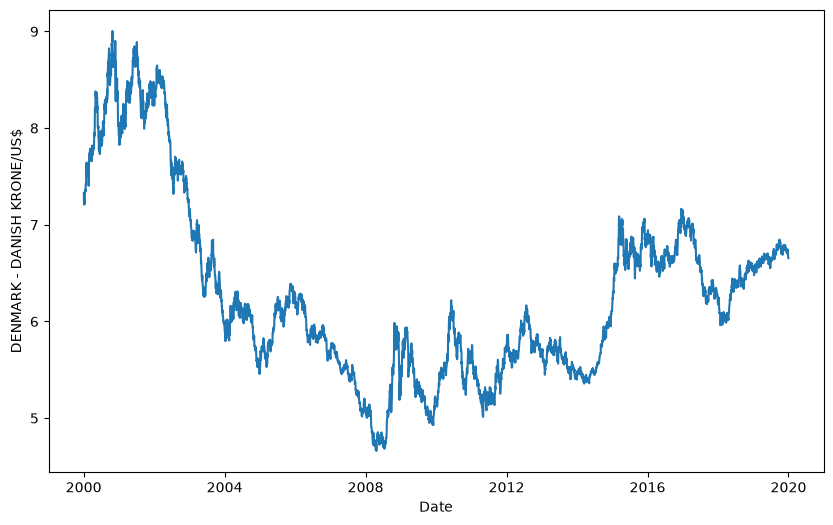

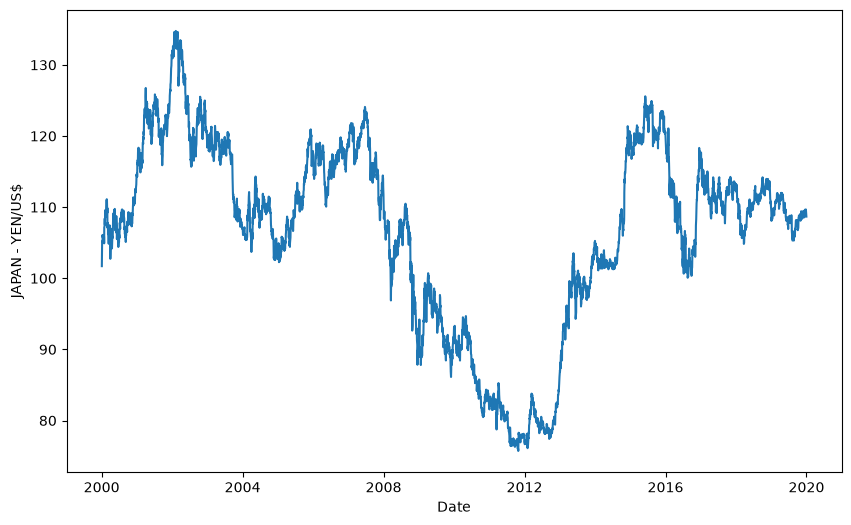

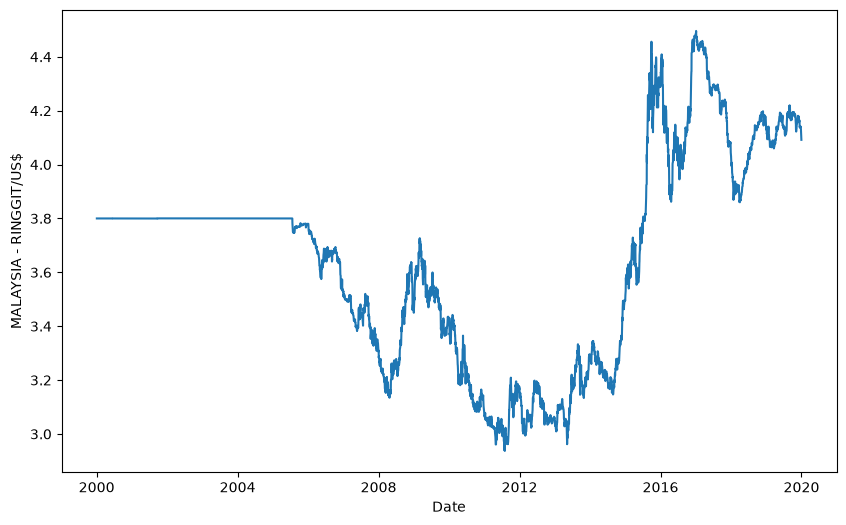

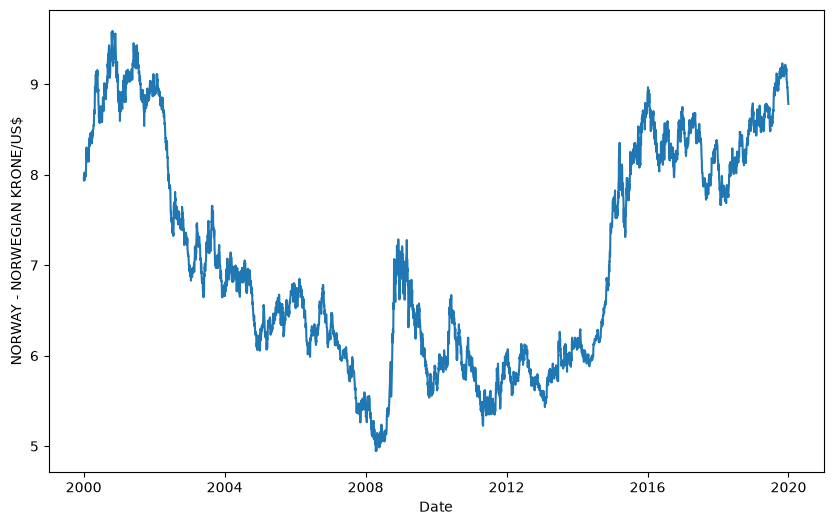

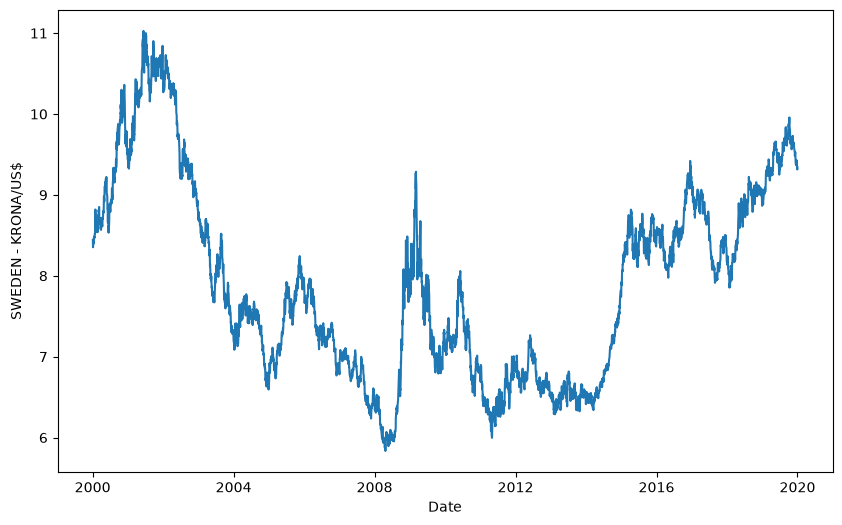

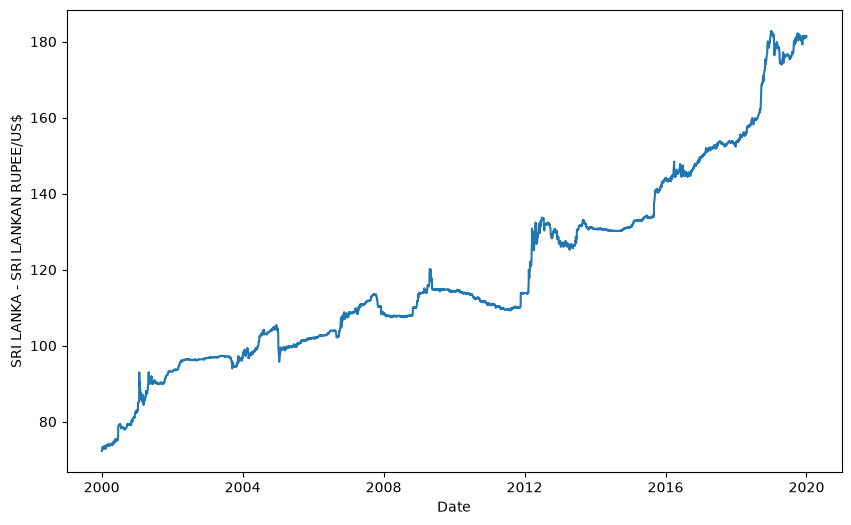

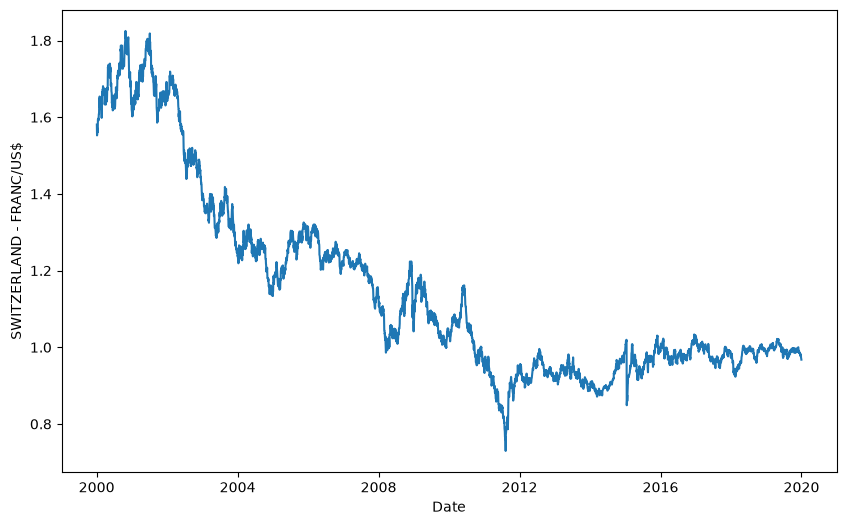

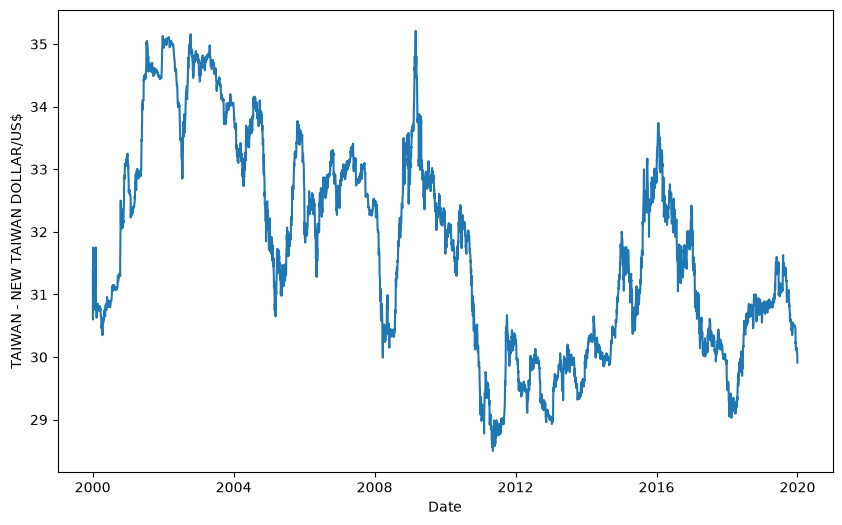

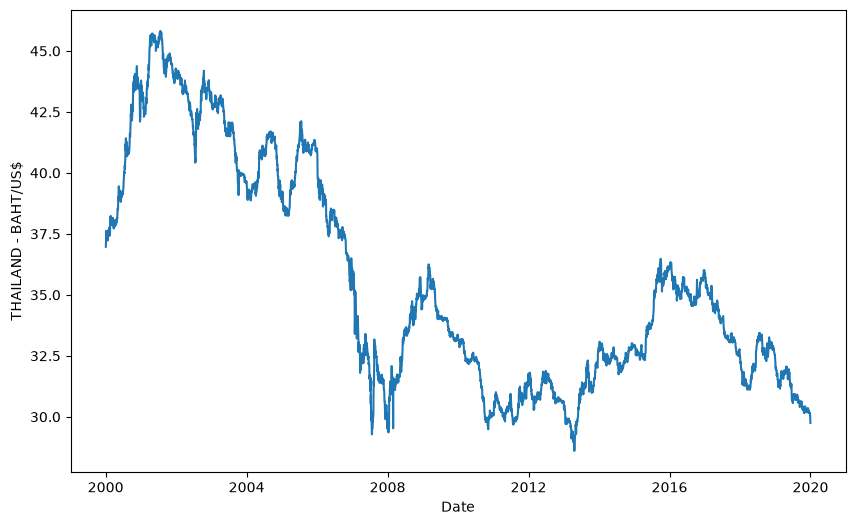

In [23]:
# Time plots

for c in col:
    plt.figure(figsize=(10,6))
    plt.plot(data["Time Serie"], data[c])
    plt.ylabel(c)
    plt.xlabel('Date')
    plt.show()

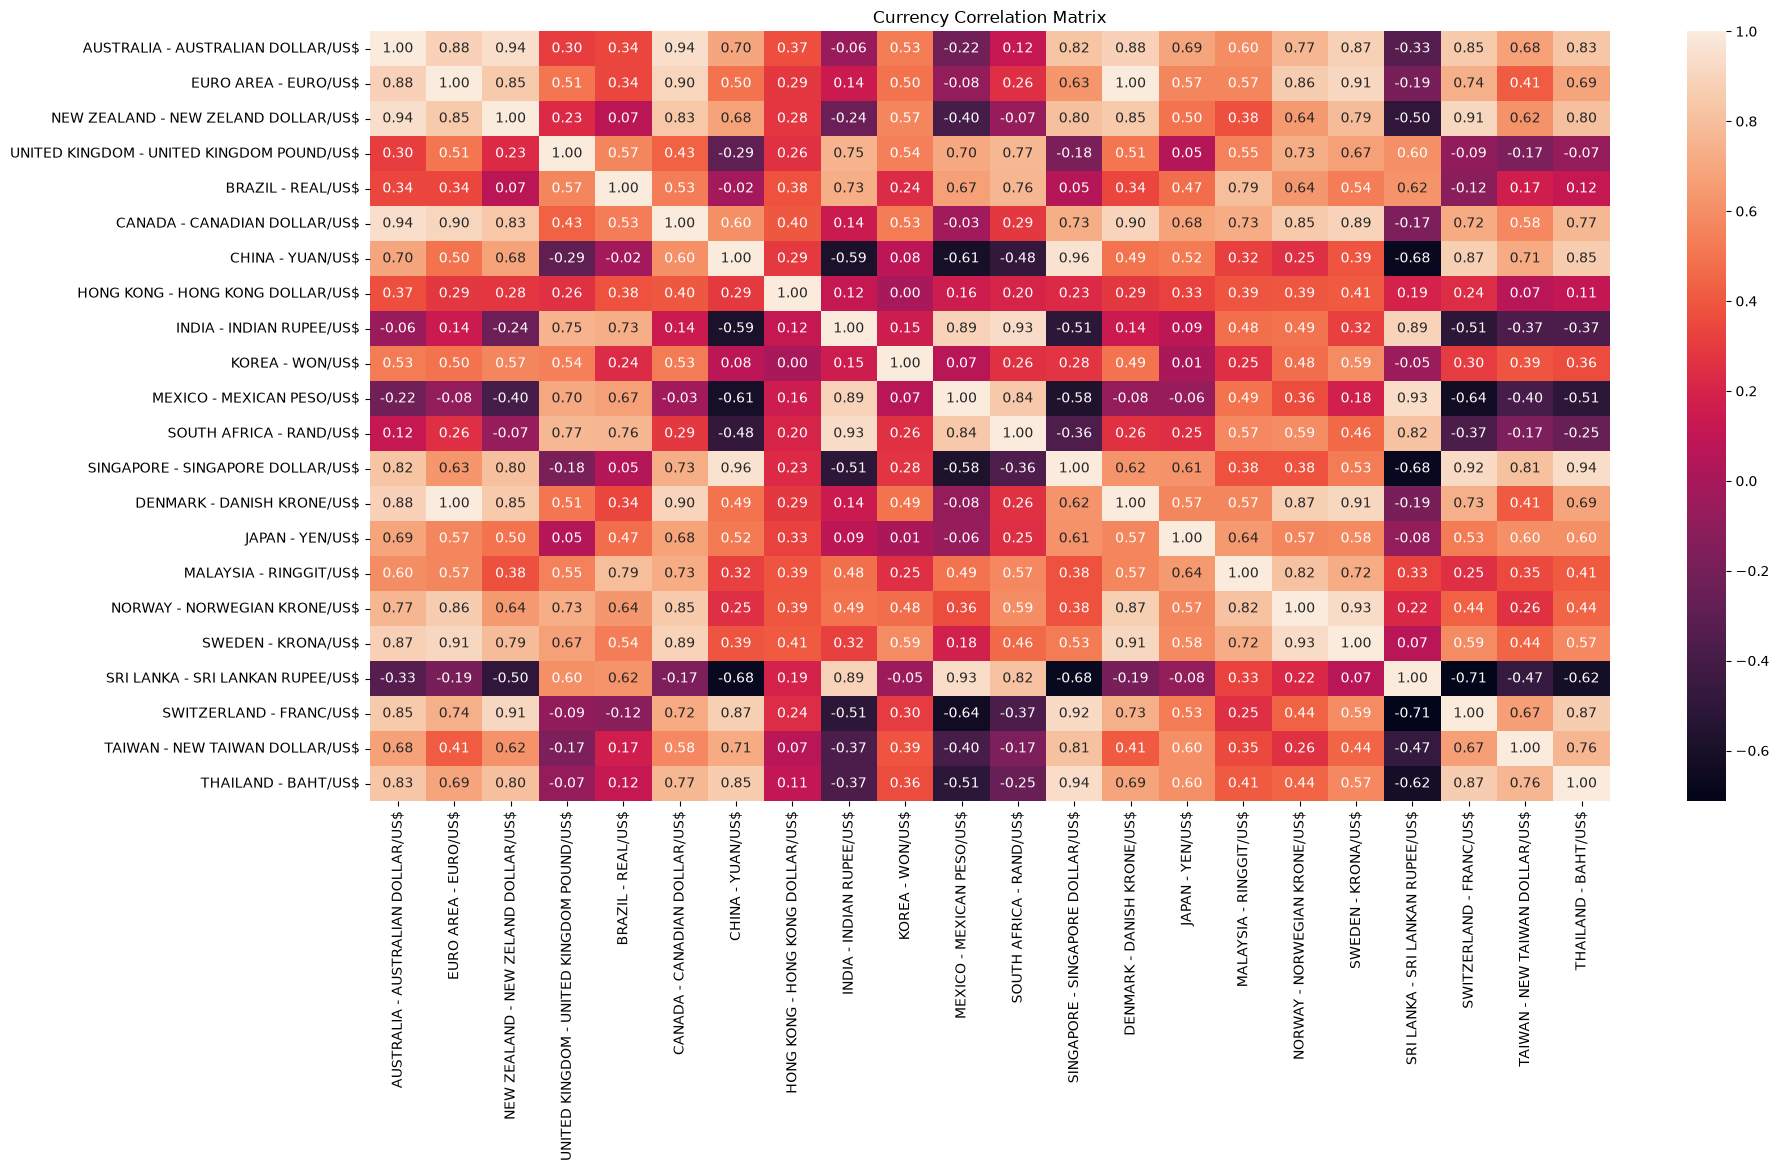

In [45]:
correlation = data[col].corr()

plt.figure(figsize=(20,10))
sns.heatmap(correlation, annot=True, fmt=".2f")
plt.title("Currency Correlation Matrix")
plt.show()

## Prediction Modelling

In [9]:
# Split data into training and test - test is last 60 days
train = data.iloc[:5157]
test = data.iloc[5157:]

In [10]:
print(train.shape)
print(test.shape)

(5157, 24)
(60, 24)


## ARIMA

In [ ]:
def run_arima(train, test):
    model = pm.auto_arima(train, seasonal=True, m=7, stepwise=True)

    forecast = model.predict(n_periods=60)
    
    mae = mean_absolute_error(test, forecast)
    rmse = np.sqrt(mean_squared_error(test, forecast))
    mape = np.mean(np.abs((test - forecast) / test)) * 100

    return {"model": model, "mae": mae, "rmse": rmse, "mape": mape}

## Prophet

In [124]:
def run_prophet(train, test):
    
    model = Prophet()
    model.fit(train)

    future = model.make_future_dataframe(periods=60, freq="D")
    forecast = model.predict(future)
    prediction = forecast["yhat"].iloc[-60:]

    mae = mean_absolute_error(test, prediction)
    rmse = np.sqrt(mean_squared_error(test, prediction))
    mape = np.mean(np.abs((test - prediction) / test)) * 100
    
    return {"model": model, "mae": mae, "rmse": rmse, "mape": mape}

## LSTM

In [50]:
def Sequential_Input_LSTM(df, input_sequence):
    df_np = df.to_numpy()
    X = []
    y = []
    
    for i in range(len(df_np) - input_sequence):
        row = [a for a in df_np[i:i + input_sequence]]
        X.append(row)
        label = df_np[i + input_sequence]
        y.append(label)
        
    return np.array(X), np.array(y)

In [125]:
def run_LSTM(data, currency, train_size=5157, test_size=60, input_sequence=30):

    values = data[currency]

    # Split data
    train_values = values.iloc[:train_size]
    test_values = values.iloc[train_size:train_size + test_size]

    # Create training sequences
    X_train, y_train = Sequential_Input_LSTM(train_values, input_sequence)

    # Create test sequences
    test_with_context = pd.concat([train_values.iloc[-input_sequence:], test_values])

    X_test, y_test = Sequential_Input_LSTM(test_with_context, input_sequence)

    # Reshape for LSTM
    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)

    X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

    # Build model

    model = Sequential()
    
    model.add(InputLayer((X_train.shape[1],n_features))) # Input layer
    model.add(LSTM(100, return_sequences = True))  # 2 LSTM layers, each with 100 units
    model.add(LSTM(100, return_sequences = True))
    model.add(LSTM(50)) # Another LSTM layer with 50 units
    model.add(Dense(8, activation = 'relu')) # 2 fully connected layers - 1 with 8 neurons
    model.add(Dense(1, activation = 'linear')) # Output layer with activation layer and 1 output

    early_stop = EarlyStopping(monitor = 'val_loss', patience = 2, restore_best_weights=True)

    # Compile model with mean squared error as loss function
    model.compile(loss = MeanSquaredError(), optimizer = Adam(learning_rate = 0.0001), metrics = [RootMeanSquaredError()])

    # Validation split
    validation_size = int(len(X_train) * 0.2)

    X_train_actual = X_train[:-validation_size]
    y_train_actual = y_train[:-validation_size]

    X_val = X_train[-validation_size:]
    y_val = y_train[-validation_size:]

    # Train
    model.fit(X_train_actual, y_train_actual, validation_data = (X_val, y_val), epochs = 10, callbacks = [early_stop], verbose=0)

    # Predict final 60 points
    y_pred = model.predict(X_test, verbose=0).flatten()

    # Metrics
    y_test = np.asarray(test_values)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    
    return {"model": model, "mae": mae, "rmse": rmse, "mape": mape}

## Run all models

In [126]:
results = []

for currency in col:

    print(f"\n{currency}")

    # ARIMA

    arima_result = run_arima(train[currency], test[currency])

    results.append({
        "Currency": currency,
        "Model": "ARIMA",
        "MAE": arima_result["mae"],
        "RMSE": arima_result["rmse"],
        "MAPE": arima_result["mape"],
        "Model_Object": arima_result["model"]
    })

    # Prophet

    prophet_train = train[["Time Serie", currency]].copy()
    prophet_train.columns = ["ds", "y"]

    prophet_result = run_prophet(prophet_train, test[currency])

    results.append({
        "Currency": currency,
        "Model": "Prophet",
        "MAE": prophet_result["mae"],
        "RMSE": prophet_result["rmse"],
        "MAPE": prophet_result["mape"],
        "Model_Object": prophet_result["model"]
    })

    # LSTM

    lstm_result = run_LSTM(data, currency)

    results.append({
        "Currency": currency,
        "Model": "LSTM",
        "MAE": lstm_result["mae"],
        "RMSE": lstm_result["rmse"],
        "MAPE": lstm_result["mape"],
        "Model_Object": lstm_result["model"]
    })


AUSTRALIA - AUSTRALIAN DOLLAR/US$


03:01:27 - cmdstanpy - INFO - Chain [1] start processing
03:01:29 - cmdstanpy - INFO - Chain [1] done processing



EURO AREA - EURO/US$


03:02:00 - cmdstanpy - INFO - Chain [1] start processing
03:02:01 - cmdstanpy - INFO - Chain [1] done processing



NEW ZEALAND - NEW ZELAND DOLLAR/US$


...

03:21:56 - cmdstanpy - INFO - Chain [1] start processing
03:21:57 - cmdstanpy - INFO - Chain [1] done processing



TAIWAN - NEW TAIWAN DOLLAR/US$


03:24:11 - cmdstanpy - INFO - Chain [1] start processing
03:24:12 - cmdstanpy - INFO - Chain [1] done processing



THAILAND - BAHT/US$


03:25:13 - cmdstanpy - INFO - Chain [1] start processing
03:25:14 - cmdstanpy - INFO - Chain [1] done processing


In [111]:
results_df = pd.DataFrame(results)

results_df

,Currency,Model,MAE,RMSE,MAPE,Model_Object
0,AUSTRALIA - AUSTRALIAN DOLLAR/US$,ARIMA,0.026002,0.028964,1.788195,"ARIMA(0,1,0)(0,0,0)[7]"
1,AUSTRALIA - AUSTRALIAN DOLLAR/US$,Prophet,0.079787,0.282466,5.456950,<prophet.forecaster.Prophet object at 0x4852b1...
2,AUSTRALIA - AUSTRALIAN DOLLAR/US$,LSTM,0.014576,0.120731,1.002322,"<Sequential name=sequential_50, built=True>"
3,EURO AREA - EURO/US$,ARIMA,0.011038,0.011882,1.225724,"ARIMA(0,1,0)(0,0,0)[7]"
4,EURO AREA - EURO/US$,Prophet,0.043414,0.208361,4.809830,<prophet.forecaster.Prophet object at 0x42f9ee...
...,...,...,...,...,...,...
61,TAIWAN - NEW TAIWAN DOLLAR/US$,Prophet,0.266526,0.516261,0.874522,<prophet.forecaster.Prophet object at 0x1785a6...
62,TAIWAN - NEW TAIWAN DOLLAR/US$,LSTM,13.386505,3.658757,43.990534,"<Sequential name=sequential_70, built=True>"
63,THAILAND - BAHT/US$,ARIMA,0.130932,0.162084,0.434076,"ARIMA(2,1,2)(0,0,0)[7]"
64,THAILAND - BAHT/US$,Prophet,0.579281,0.761105,1.916241,<prophet.forecaster.Prophet object at 0x4073e5...


In [113]:
best_models = (results_df.loc[results_df.groupby("Currency")["MAE"].idxmin()].reset_index(drop=True))

best_models

,Currency,Model,MAE,RMSE,MAPE,Model_Object
0,AUSTRALIA - AUSTRALIAN DOLLAR/US$,LSTM,0.014576,0.120731,1.002322,"<Sequential name=sequential_50, built=True>"
1,BRAZIL - REAL/US$,ARIMA,0.069798,0.083362,1.685351,"ARIMA(0,1,0)(0,0,0)[7]"
2,CANADA - CANADIAN DOLLAR/US$,LSTM,0.008305,0.091131,0.629947,"<Sequential name=sequential_55, built=True>"
3,CHINA - YUAN/US$,Prophet,0.153702,0.392048,2.182470,<prophet.forecaster.Prophet object at 0x1783b0...
4,DENMARK - DANISH KRONE/US$,ARIMA,0.079947,0.086611,1.188390,"ARIMA(0,1,0)(0,0,0)[7]"
5,EURO AREA - EURO/US$,LSTM,0.005345,0.073108,0.593611,"<Sequential name=sequential_51, built=True>"
6,HONG KONG - HONG KONG DOLLAR/US$,ARIMA,0.021752,0.028969,0.278650,"ARIMA(0,1,2)(0,0,0)[7]"
7,INDIA - INDIAN RUPEE/US$,ARIMA,0.325930,0.376405,0.457605,"ARIMA(3,1,3)(0,0,1)[7] intercept"
8,JAPAN - YEN/US$,ARIMA,1.814500,1.868105,1.664958,"ARIMA(0,1,0)(0,0,0)[7]"
9,KOREA - WON/US$,ARIMA,21.030427,23.958279,1.802794,"ARIMA(2,1,2)(0,0,0)[7]"


## Save models

In [117]:
os.makedirs("models", exist_ok=True)

In [ ]:
def get_model_filename(currency):
    filename = (
        currency
        .replace("/", "_")
        .replace(" ", "_")
        .replace("$", "")
        .replace("-", "_")
    )
    return filename

In [ ]:
metadata = []

for _, row in best_models.iterrows():

    currency = row["Currency"]
    model_type = row["Model"]
    model_obj = row["Model_Object"]

    filename = get_model_filename(currency)

    # Save LSTM models as keras
    if model_type == "LSTM":
        model_filename = f"{filename}_model.keras"
        path = os.path.join("models", model_filename)
        model_obj.save(path)

    else:
        model_filename = f"{filename}_model.pkl"
        path = os.path.join("models", model_filename)
        joblib.dump(model_obj, path)

    metadata.append({
        "Currency": currency,
        "Model": model_type,
        "Filename": model_filename
    })

    print(f"Saved {model_type} model for {currency} -> {path}")

# Save metadata so Streamlit knows what each .pkl contains
metadata_df = pd.DataFrame(metadata)

metadata_df.to_csv("models/model_metadata.csv", index=False)

Saved LSTM model for AUSTRALIA - AUSTRALIAN DOLLAR/US$ -> models/AUSTRALIA___AUSTRALIAN_DOLLAR_US_model.keras
Saved ARIMA model for BRAZIL - REAL/US$ -> models/BRAZIL___REAL_US_model.pkl
Saved LSTM model for CANADA - CANADIAN DOLLAR/US$ -> models/CANADA___CANADIAN_DOLLAR_US_model.keras
Saved Prophet model for CHINA - YUAN/US$ -> models/CHINA___YUAN_US_model.pkl
Saved ARIMA model for DENMARK - DANISH KRONE/US$ -> models/DENMARK___DANISH_KRONE_US_model.pkl
Saved LSTM model for EURO AREA - EURO/US$ -> models/EURO_AREA___EURO_US_model.keras
Saved ARIMA model for HONG KONG - HONG KONG DOLLAR/US$ -> models/HONG_KONG___HONG_KONG_DOLLAR_US_model.pkl
Saved ARIMA model for INDIA - INDIAN RUPEE/US$ -> models/INDIA___INDIAN_RUPEE_US_model.pkl
Saved ARIMA model for JAPAN - YEN/US$ -> models/JAPAN___YEN_US_model.pkl
Saved ARIMA model for KOREA - WON/US$ -> models/KOREA___WON_US_model.pkl
Saved LSTM model for MALAYSIA - RINGGIT/US$ -> models/MALAYSIA___RINGGIT_US_model.keras
Saved ARIMA model for MEX